# Goal: Fairness Metrics Computation
The goal of this notebook is given:
- a dataset D
- a target variable
- a sensible attribute
- a legittimate attribute (needed only for one specific metric)

it computes the statistical fairness metrics presented in Verma and Rubin paper https://dl.acm.org/doi/pdf/10.1145/3194770.3194776 + Aequitas metrics https://arxiv.org/pdf/1811.05577.pdf.

The running example is the Credit Score dataset https://www.kaggle.com/datasets/kabure/german-credit-data-with-risk



## Only for Colab environment

In [1]:
#online for colab environment
from google.colab import drive
drive.mount('/content/drive', force_remount=True)

Mounted at /content/drive


#Import e Preprocessing

In [2]:
%cd /content/drive/MyDrive/USA/preprocessing/
from distribution_utils import *

/content/drive/MyDrive/USA/preprocessing


In [3]:
%cd /content/drive/MyDrive/USA/AdultCensus

/content/drive/MyDrive/USA/AdultCensus


## Load the dataset

In [ ]:
dataset_path = 'adult.csv'
#dataset_path = 'german.csv'
df=pd.read_csv(dataset_path)
df.head(10)

,age,workclass,fnlwgt,education,education.num,marital.status,occupation,relationship,race,sex,capital.gain,capital.loss,hours.per.week,native.country,income
0,90,?,77053,HS-grad,9,Widowed,?,Not-in-family,White,Female,0,4356,40,United-States,<=50K
1,82,Private,132870,HS-grad,9,Widowed,Exec-managerial,Not-in-family,White,Female,0,4356,18,United-States,<=50K
2,66,?,186061,Some-college,10,Widowed,?,Unmarried,Black,Female,0,4356,40,United-States,<=50K
3,54,Private,140359,7th-8th,4,Divorced,Machine-op-inspct,Unmarried,White,Female,0,3900,40,United-States,<=50K
4,41,Private,264663,Some-college,10,Separated,Prof-specialty,Own-child,White,Female,0,3900,40,United-States,<=50K
5,34,Private,216864,HS-grad,9,Divorced,Other-service,Unmarried,White,Female,0,3770,45,United-States,<=50K
6,38,Private,150601,10th,6,Separated,Adm-clerical,Unmarried,White,Male,0,3770,40,United-States,<=50K
7,74,State-gov,88638,Doctorate,16,Never-married,Prof-specialty,Other-relative,White,Female,0,3683,20,United-States,>50K
8,68,Federal-gov,422013,HS-grad,9,Divorced,Prof-specialty,Not-in-family,White,Female,0,3683,40,United-States,<=50K
9,41,Private,70037,Some-college,10,Never-married,Craft-repair,Unmarried,White,Male,0,3004,60,?,>50K


In [ ]:
print(df.race.unique())

['White' 'Black' 'Asian-Pac-Islander' 'Other' 'Amer-Indian-Eskimo']


In [ ]:
print(df['native.country'].unique())

['United-States' '?' 'Mexico' 'Greece' 'Vietnam' 'China' 'Taiwan' 'India'
 'Philippines' 'Trinadad&Tobago' 'Canada' 'South' 'Holand-Netherlands'
 'Puerto-Rico' 'Poland' 'Iran' 'England' 'Germany' 'Italy' 'Japan' 'Hong'
 'Honduras' 'Cuba' 'Ireland' 'Cambodia' 'Peru' 'Nicaragua'
 'Dominican-Republic' 'Haiti' 'El-Salvador' 'Hungary' 'Columbia'
 'Guatemala' 'Jamaica' 'Ecuador' 'France' 'Yugoslavia' 'Scotland'
 'Portugal' 'Laos' 'Thailand' 'Outlying-US(Guam-USVI-etc)']


In [ ]:
print(df['education'].unique())

['HS-grad' 'Some-college' '7th-8th' '10th' 'Doctorate' 'Prof-school'
 'Bachelors' 'Masters' '11th' 'Assoc-acdm' 'Assoc-voc' '1st-4th' '5th-6th'
 '12th' '9th' 'Preschool']


## Inputs

In [ ]:
feature_cols= df.columns

## Preprocessing

In [ ]:
df[feature_cols].isna().sum()

,0
age,0
workclass,0
fnlwgt,0
education,0
education.num,0
marital.status,0
occupation,0
relationship,0
race,0
sex,0


In [ ]:
for c in feature_cols:
   print(c, (df[c] == '?').sum())

age 0
workclass 1836
fnlwgt 0
education 0
education.num 0
marital.status 0
occupation 1843
relationship 0
race 0
sex 0
capital.gain 0
capital.loss 0
hours.per.week 0
native.country 583
income 0


In [ ]:
df = df.drop(columns=['native.country', 'fnlwgt', 'occupation', 'workclass', 'education'])
df.head()

,age,education.num,marital.status,relationship,race,sex,capital.gain,capital.loss,hours.per.week,income
0,90,9,Widowed,Not-in-family,White,Female,0,4356,40,<=50K
1,82,9,Widowed,Not-in-family,White,Female,0,4356,18,<=50K
2,66,10,Widowed,Unmarried,Black,Female,0,4356,40,<=50K
3,54,4,Divorced,Unmarried,White,Female,0,3900,40,<=50K
4,41,10,Separated,Own-child,White,Female,0,3900,40,<=50K


In [ ]:
print(len(df))
df = df.dropna()
df.head()
print(len(df))

32561
32561


In [ ]:
from sklearn.preprocessing import LabelEncoder

# Initialize encoder
encoder = LabelEncoder()

# Fit and transform column
df['race'] = encoder.fit_transform(df['race'])
df.head()

,age,education.num,marital.status,relationship,race,sex,capital.gain,capital.loss,hours.per.week,income
0,90,9,Widowed,Not-in-family,4,Female,0,4356,40,<=50K
1,82,9,Widowed,Not-in-family,4,Female,0,4356,18,<=50K
2,66,10,Widowed,Unmarried,2,Female,0,4356,40,<=50K
3,54,4,Divorced,Unmarried,4,Female,0,3900,40,<=50K
4,41,10,Separated,Own-child,4,Female,0,3900,40,<=50K


In [ ]:
mapping = {category: code for code, category in enumerate(encoder.classes_)}
print(mapping)

{'Amer-Indian-Eskimo': 0, 'Asian-Pac-Islander': 1, 'Black': 2, 'Other': 3, 'White': 4}


In [ ]:
df['sex'] = df['sex'].replace({'Female': 0, 'Male': 1})

<ipython-input-61-426cec34a599>:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df['sex'] = df['sex'].replace({'Female': 0, 'Male': 1})


In [ ]:
df['income'] = df['income'].replace({'<=50K': 0, '>50K': 1})
df.head()

<ipython-input-62-7de08b99d98a>:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df['income'] = df['income'].replace({'<=50K': 0, '>50K': 1})


,age,education.num,marital.status,relationship,race,sex,capital.gain,capital.loss,hours.per.week,income
0,90,9,Widowed,Not-in-family,4,0,0,4356,40,0
1,82,9,Widowed,Not-in-family,4,0,0,4356,18,0
2,66,10,Widowed,Unmarried,2,0,0,4356,40,0
3,54,4,Divorced,Unmarried,4,0,0,3900,40,0
4,41,10,Separated,Own-child,4,0,0,3900,40,0


In [ ]:
df['marital.status'] = encoder.fit_transform(df['marital.status'])
mapping = {category: code for code, category in enumerate(encoder.classes_)}
print(mapping)
df['relationship'] = encoder.fit_transform(df['relationship'])
mapping = {category: code for code, category in enumerate(encoder.classes_)}
print(mapping)
df.head()

{'Divorced': 0, 'Married-AF-spouse': 1, 'Married-civ-spouse': 2, 'Married-spouse-absent': 3, 'Never-married': 4, 'Separated': 5, 'Widowed': 6}
{'Husband': 0, 'Not-in-family': 1, 'Other-relative': 2, 'Own-child': 3, 'Unmarried': 4, 'Wife': 5}


,age,education.num,marital.status,relationship,race,sex,capital.gain,capital.loss,hours.per.week,income
0,90,9,6,1,4,0,0,4356,40,0
1,82,9,6,1,4,0,0,4356,18,0
2,66,10,6,4,2,0,0,4356,40,0
3,54,4,0,4,4,0,0,3900,40,0
4,41,10,5,3,4,0,0,3900,40,0


In [ ]:
df.loc[df['age'].between(17, 25, 'both'), 'age'] = 0
df.loc[df['age'].between(25, 40, 'right'), 'age'] = 1
df.loc[df['age'].between(40, 75, 'right'), 'age'] = 2
df.loc[df['age'].between(75, 90, 'right'), 'age'] = 3
df.head()

,age,education.num,marital.status,relationship,race,sex,capital.gain,capital.loss,hours.per.week,income
0,3,9,6,1,4,0,0,4356,40,0
1,3,9,6,1,4,0,0,4356,18,0
2,2,10,6,4,2,0,0,4356,40,0
3,2,4,0,4,4,0,0,3900,40,0
4,2,10,5,3,4,0,0,3900,40,0


In [ ]:
df.age.unique()

array([3, 2, 1, 0])

In [ ]:
df.loc[df['age'].between(11, 25, 'both'), 'age'] = 0
df.loc[df['age'].between(25, 40, 'right'), 'age'] = 1
df.loc[df['age'].between(40, 75, 'right'), 'age'] = 2
df.loc[df['age'].between(75, 90, 'right'), 'age'] = 3
df.head()

,age,education.num,marital.status,relationship,race,sex,capital.gain,capital.loss,hours.per.week,income
0,3,9,6,1,4,0,0,4356,40,0
1,3,9,6,1,4,0,0,4356,18,0
2,2,10,6,4,2,0,0,4356,40,0
3,2,4,0,4,4,0,0,3900,40,0
4,2,10,5,3,4,0,0,3900,40,0


In [ ]:
df = df.rename(columns={'education.num': 'edu'})

'HS-grad' 'Some-college' '7th-8th' '10th' 'Doctorate' 'Prof-school'
 'Bachelors' 'Masters' '11th' 'Assoc-acdm' 'Assoc-voc' '1st-4th' '5th-6th'
 '12th' '9th' 'Preschool'

In [ ]:
df.loc[df['edu'].between(1, 6, 'both'), 'edu'] = 0
df.loc[df['edu'].between(6, 11, 'right'), 'edu'] = 1
df.loc[df['edu'].between(11, 16, 'right'), 'edu'] = 2
df.head()

,age,edu,marital.status,relationship,race,sex,capital.gain,capital.loss,hours.per.week,income
0,3,1,6,1,4,0,0,4356,40,0
1,3,1,6,1,4,0,0,4356,18,0
2,2,1,6,4,2,0,0,4356,40,0
3,2,0,0,4,4,0,0,3900,40,0
4,2,1,5,3,4,0,0,3900,40,0


In [ ]:
print(df['edu'].unique())

[1 0 2]


In [ ]:
df.describe()

,age,edu,marital.status,relationship,race,sex,capital.gain,capital.loss,hours.per.week,income
count,32561.000000,32561.000000,32561.000000,32561.000000,32561.000000,32561.000000,32561.000000,32561.000000,32561.000000,32561.000000
mean,1.223365,1.199287,2.611836,1.446362,3.665858,0.669205,1077.648844,87.303830,40.437456,0.240810
std,0.762940,0.567491,1.506222,1.606771,0.848806,0.470506,7385.292085,402.960219,12.347429,0.427581
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000
25%,1.000000,1.000000,2.000000,0.000000,4.000000,0.000000,0.000000,0.000000,40.000000,0.000000
50%,1.000000,1.000000,2.000000,1.000000,4.000000,1.000000,0.000000,0.000000,40.000000,0.000000
75%,2.000000,2.000000,4.000000,3.000000,4.000000,1.000000,0.000000,0.000000,45.000000,0.000000
max,3.000000,2.000000,6.000000,5.000000,4.000000,1.000000,99999.000000,4356.000000,99.000000,1.000000


# Save preprocessed datasets

In [ ]:
df.to_csv("adult-preprocessed.csv", sep=',', index=False, encoding='utf-8')

# Distribution Analysis

In [4]:
protected_attributes =['age', 'sex', 'race', 'edu']
target = 'income'
dataset_path= 'adult-preprocessed.csv'
df=pd.read_csv(dataset_path)

In [6]:
def plot_percentage(dataset_path, target, protected_attributes):
    pairs_dict = {}
    for i in range(1, len(protected_attributes) + 1):
        pairs_dict[i] = ['-'.join(pair) for pair in combinations(protected_attributes, i)]

    df = pd.read_csv(dataset_path)

    for i in range(1, len(protected_attributes) + 1):
        for sensible_attribute in pairs_dict[i]:
            s = sensible_attribute.split('-')
            df = pd.read_csv(dataset_path)

            if len(s) > 1:
                df[sensible_attribute] = reduce(lambda x, y: x.astype(str) + y.astype(str), [df[col] for col in s])
                df = df.drop(columns=s)

            # Calculate percentages
            counts_C0 = df[df[target] == 0][sensible_attribute].value_counts()
            counts_C1 = df[df[target] == 1][sensible_attribute].value_counts()
            perc = (counts_C1 / counts_C0) * 100

            # Sort x labels in ascending order
            perc = perc.sort_index(key=lambda x: pd.to_numeric(x, errors='coerce'))  # Converts labels to numbers for sorting

            # Create figure
            plt.figure(figsize=(8, 5))
            ax = perc.plot(kind='bar', color='skyblue', edgecolor='black')

            # Set y-axis limit to avoid overlapping
            plt.ylim(0, perc.max() * 1.2)  # Adds space above the highest bar

            # Add labels to bars
            for i, v in enumerate(perc):
                plt.text(i, v + (perc.max() * 0.05), f"{v:.1f}%",
                         ha='center', fontsize=10, fontweight='bold',
                         bbox=dict(facecolor='white', edgecolor='black', boxstyle='round,pad=0.2'))

            # Customize plot
            plt.xlabel(sensible_attribute)
            plt.ylabel("Percentage (%)")
            plt.title(f"Percentage of Class=1 over Class=0 for {sensible_attribute}")
            plt.xticks(rotation=45)
            plt.grid(axis='y', linestyle='--', alpha=0.7)

            # Show plot
            plt.show()


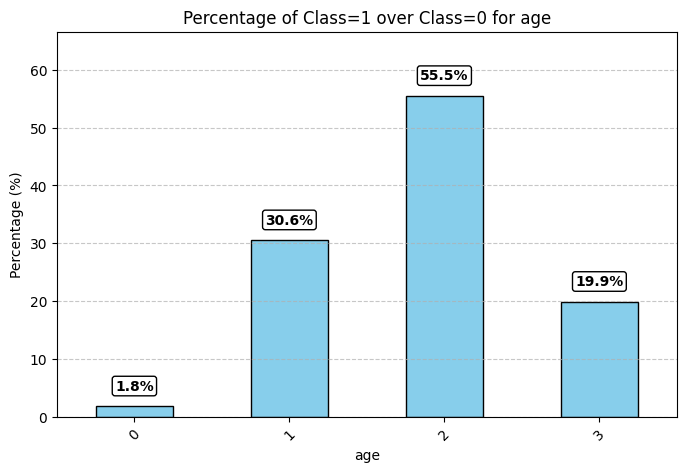

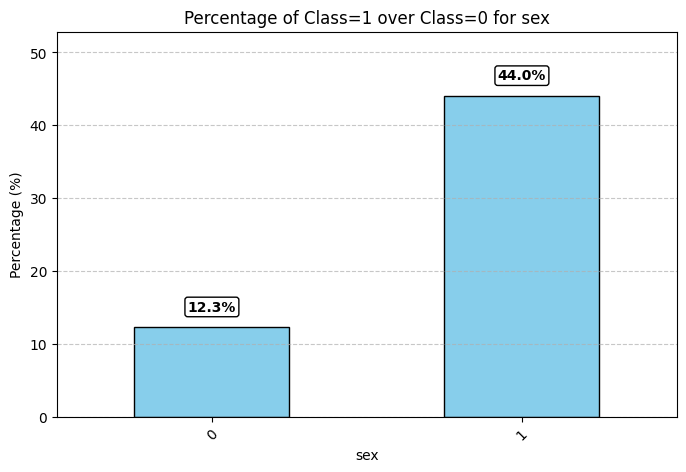

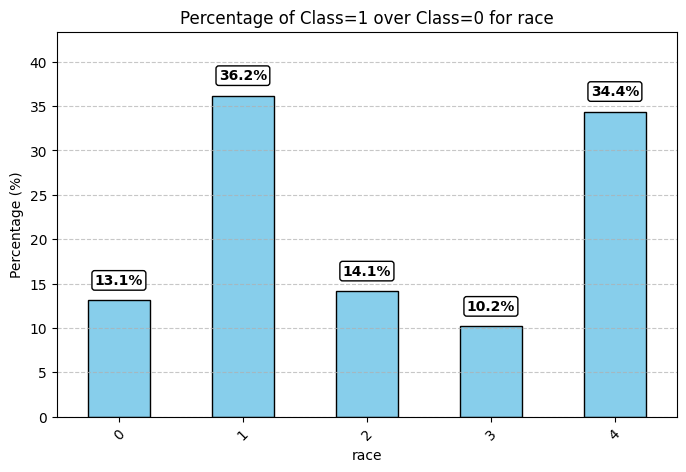

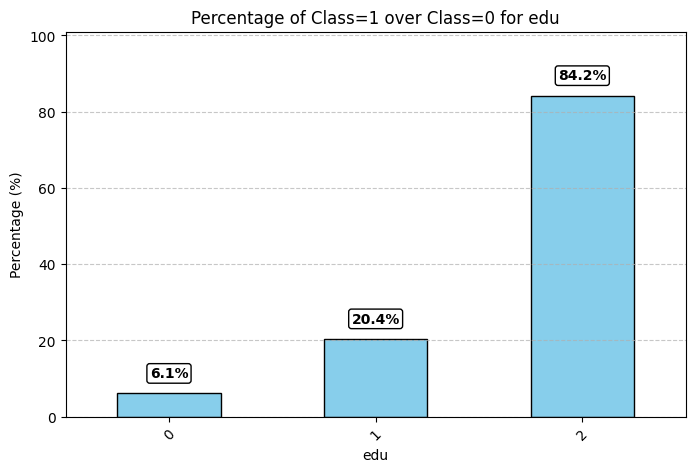

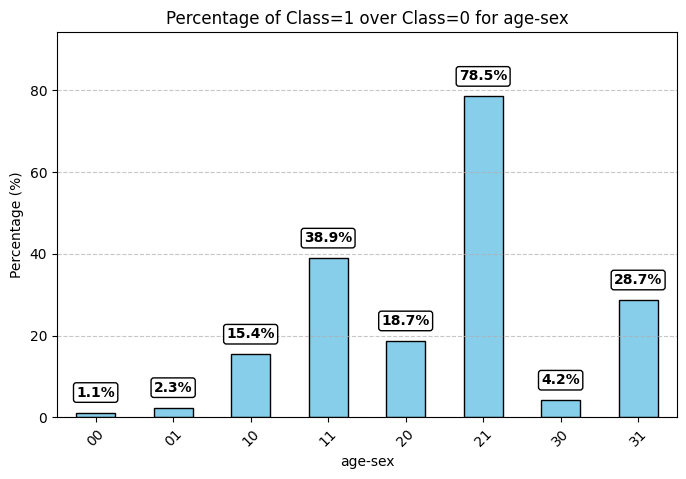

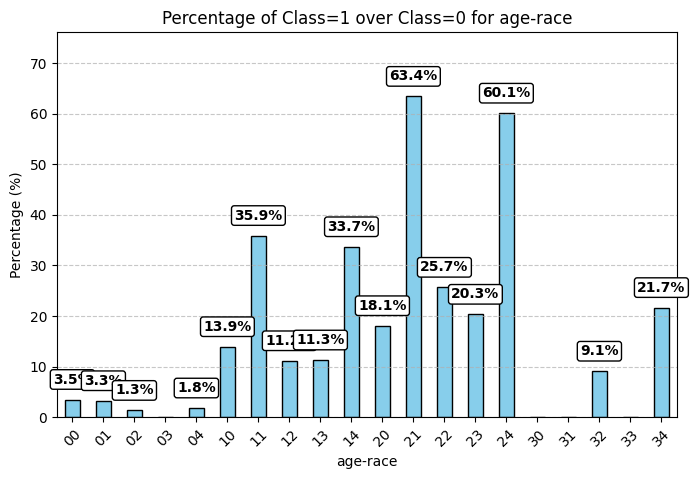

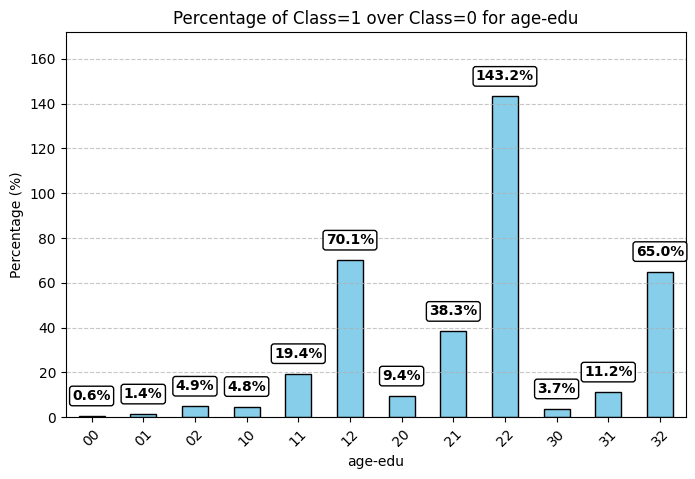

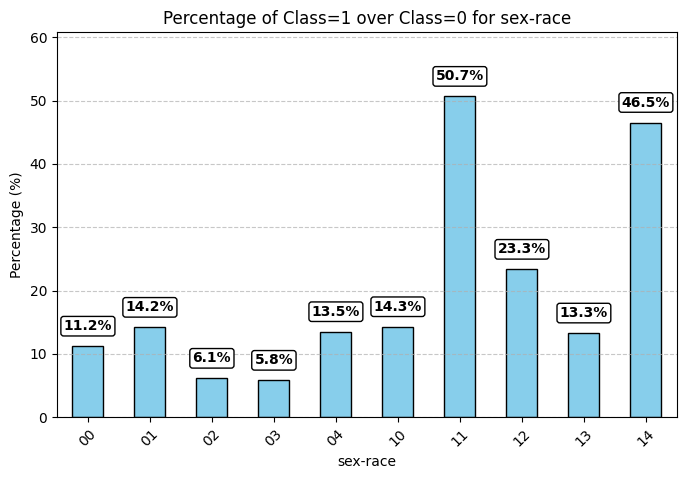

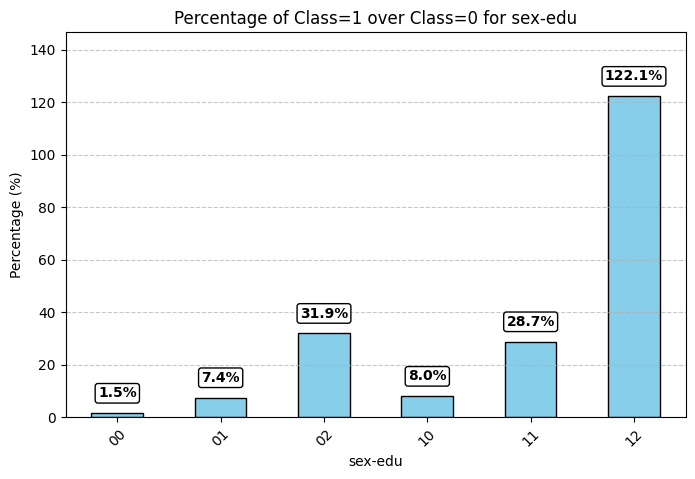

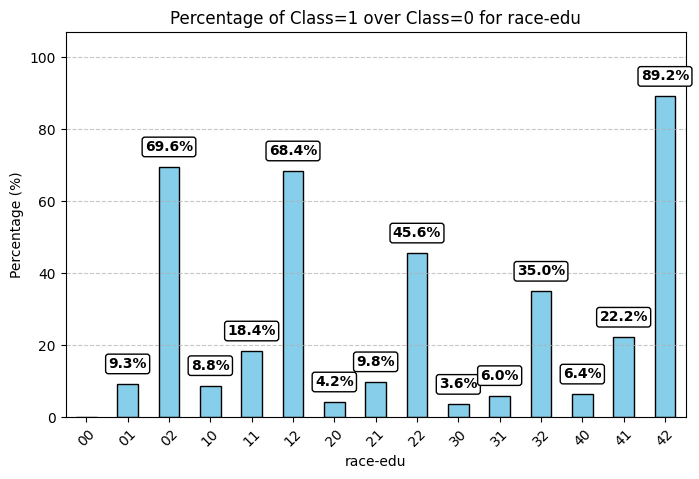

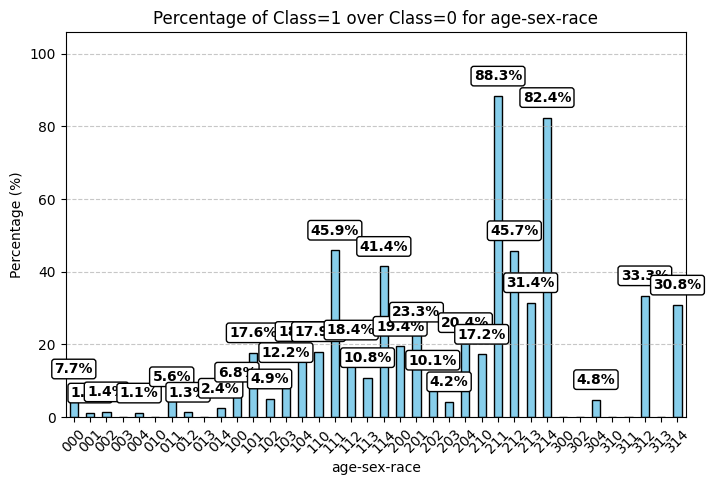

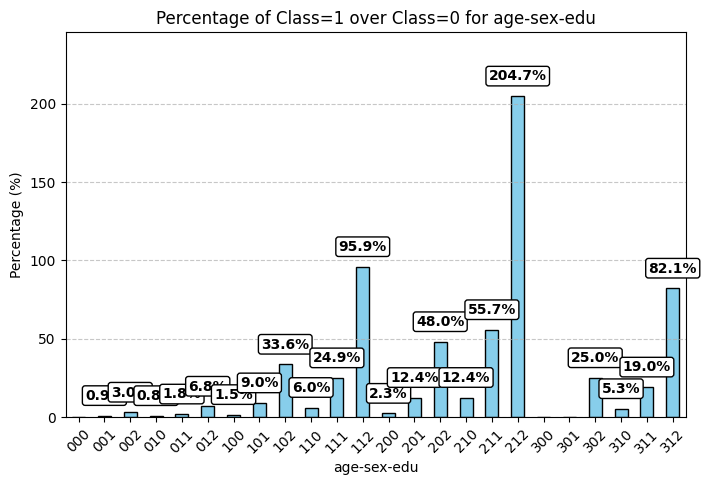

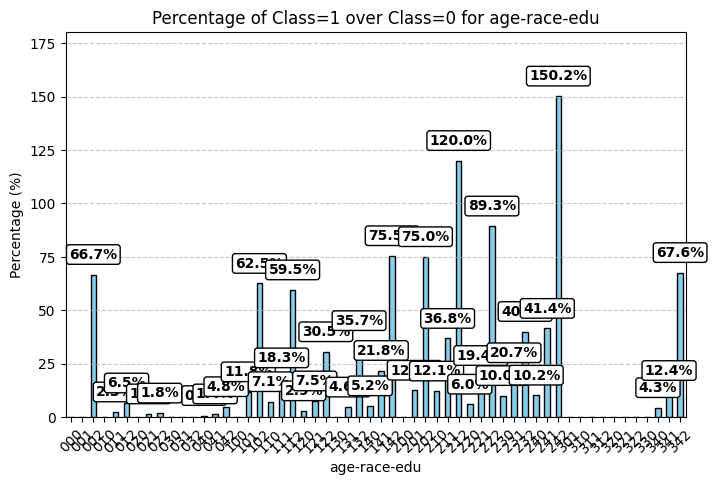

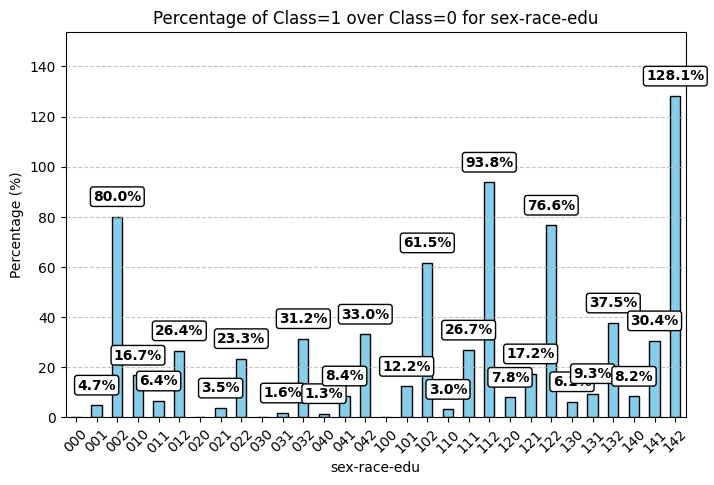

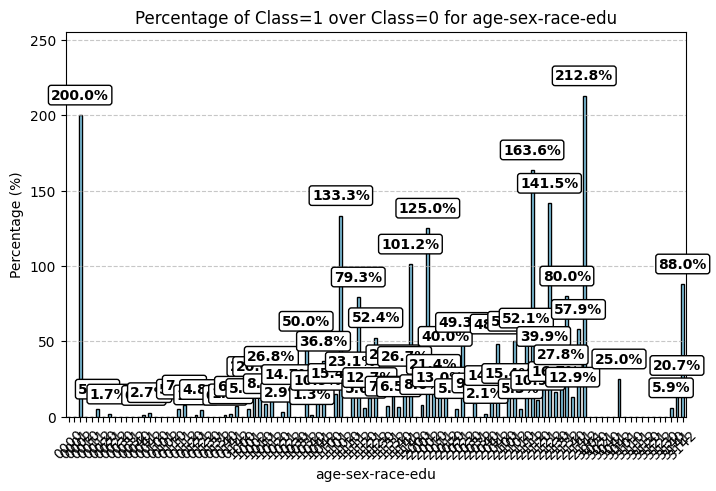

In [7]:
plot_percentage(dataset_path, target, protected_attributes)

['age']


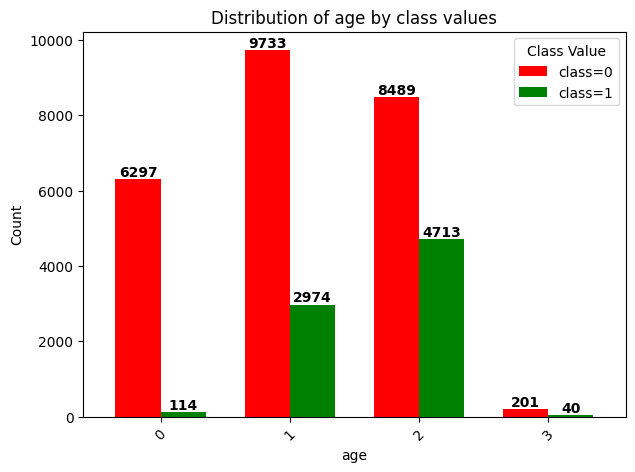

['sex']


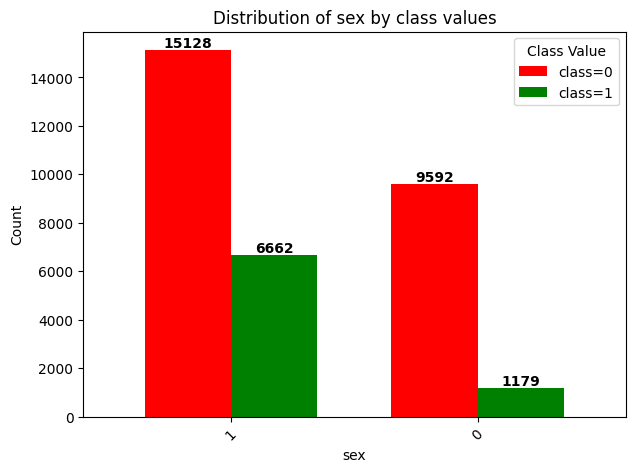

['race']


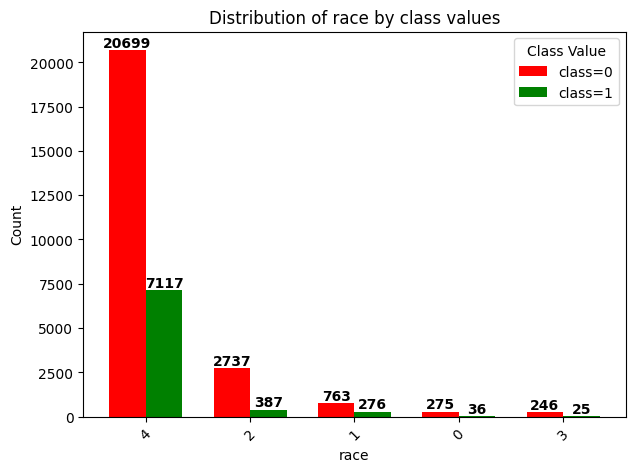

['edu']


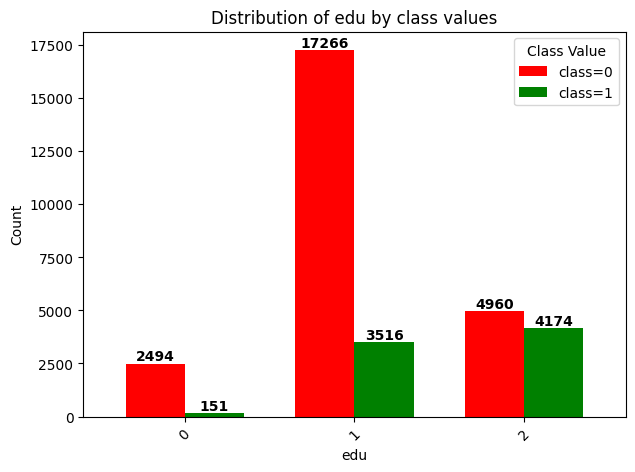

['age', 'sex']


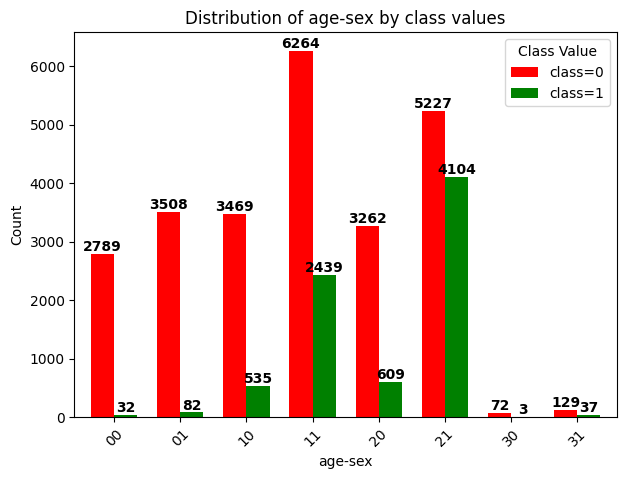

['age', 'race']


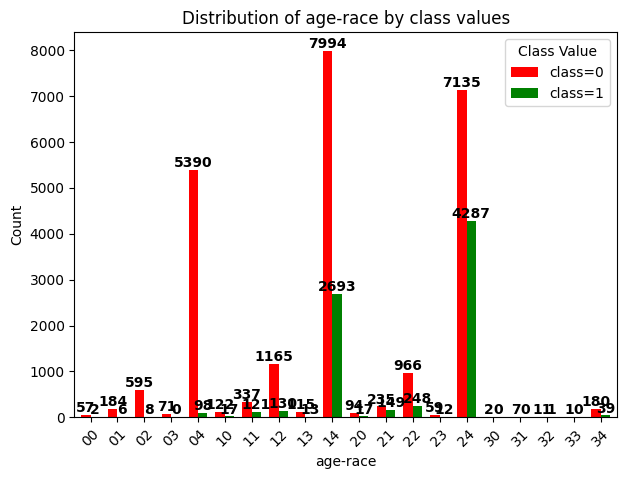

['age', 'edu']


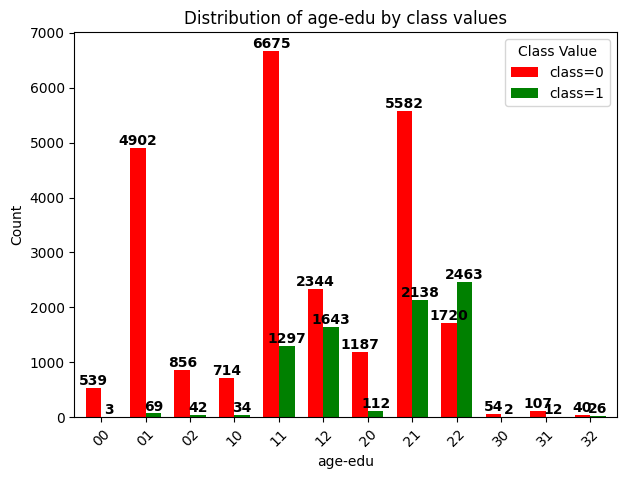

['sex', 'race']


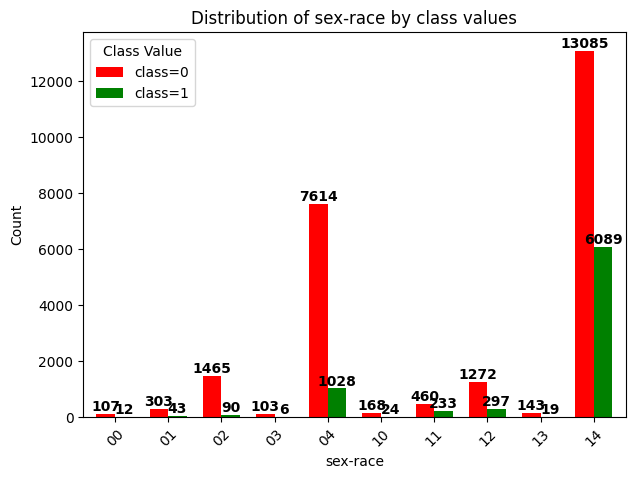

['sex', 'edu']


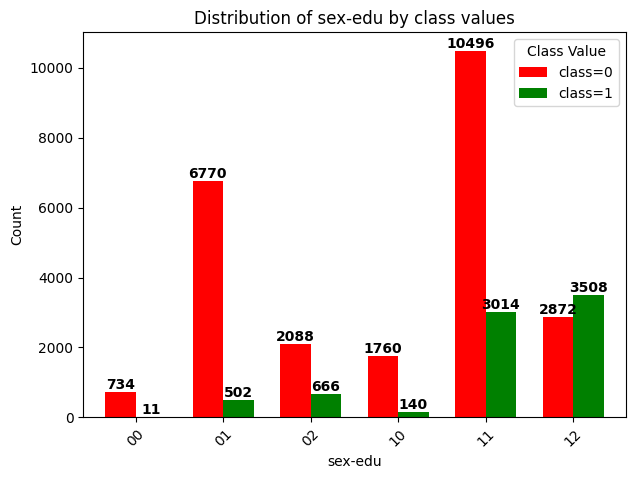

['race', 'edu']


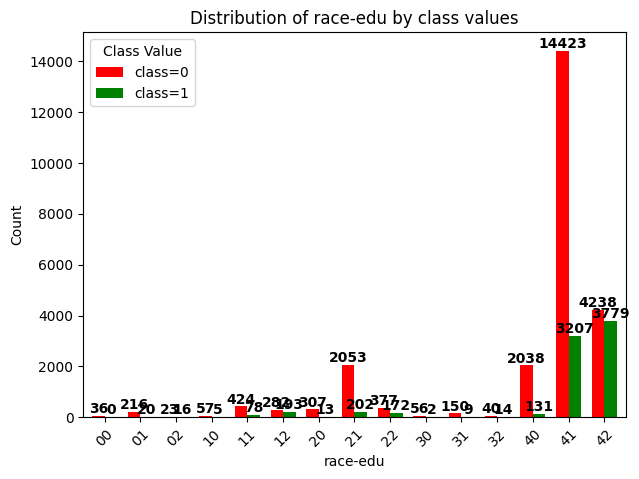

['age', 'sex', 'race']


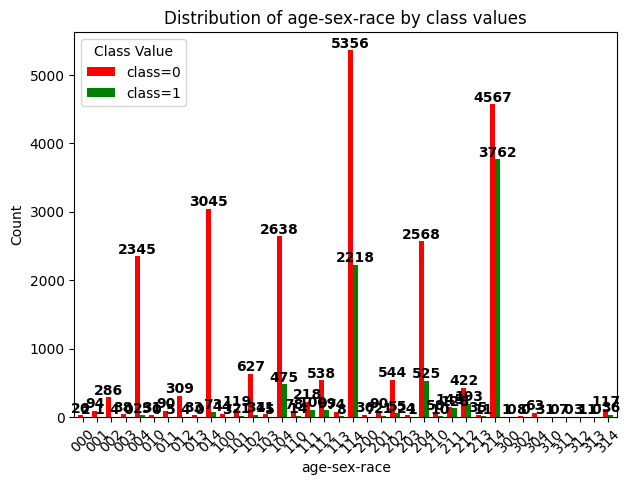

['age', 'sex', 'edu']


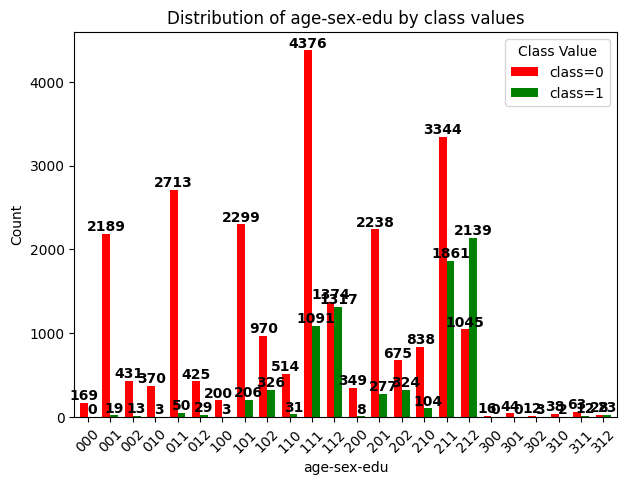

['age', 'race', 'edu']


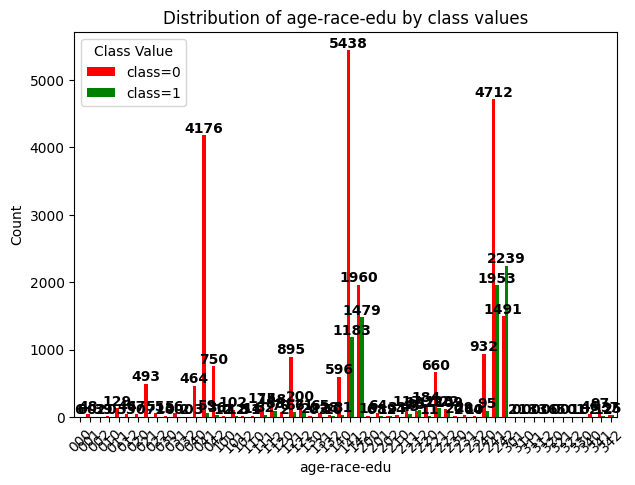

['sex', 'race', 'edu']


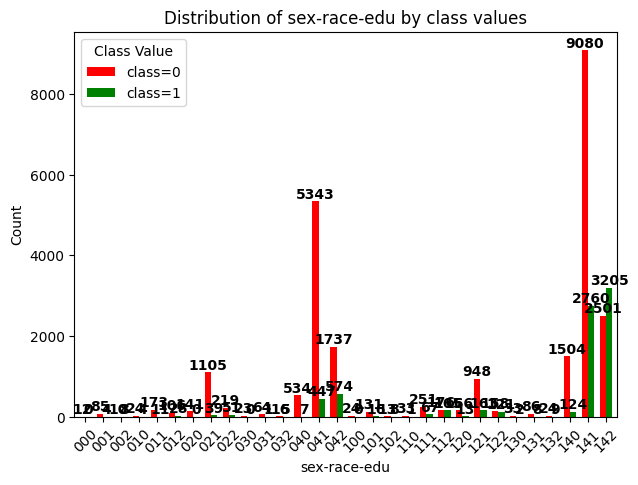

['age', 'sex', 'race', 'edu']


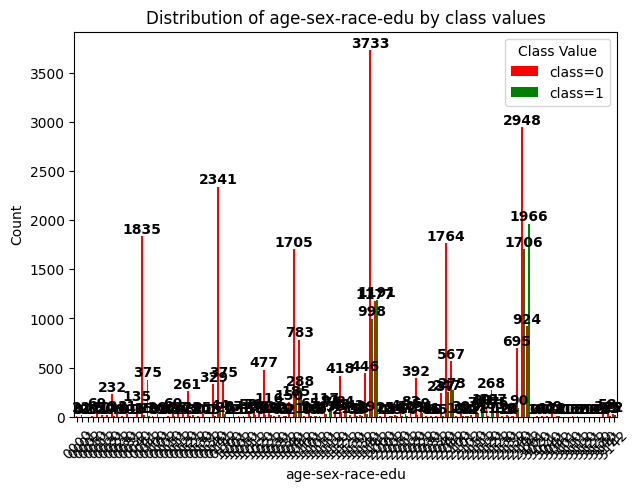

In [ ]:
create_all_plots(dataset_path, protected_attributes, target)

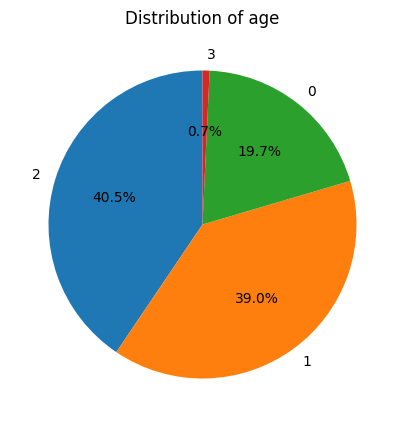

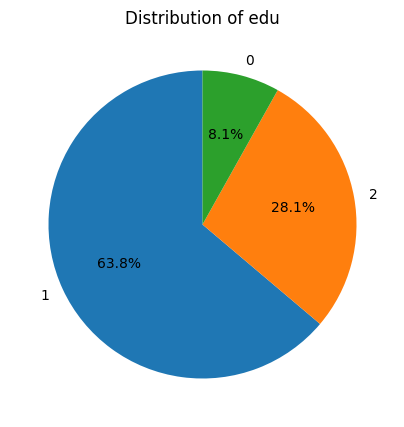

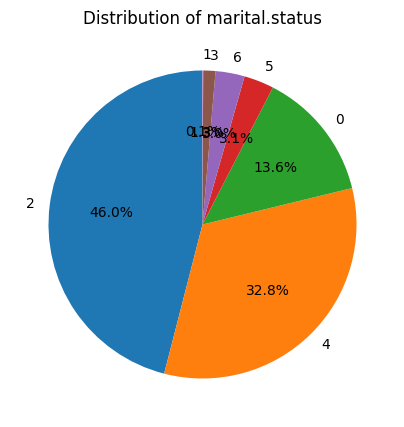

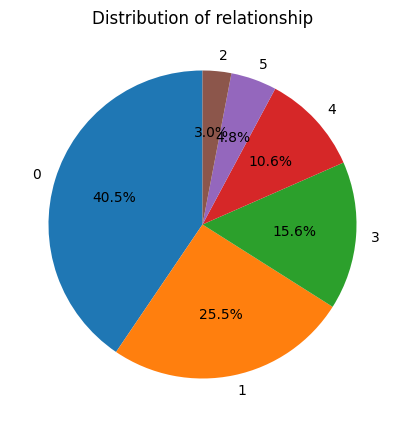

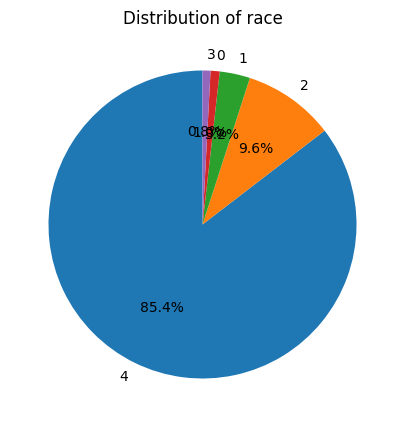

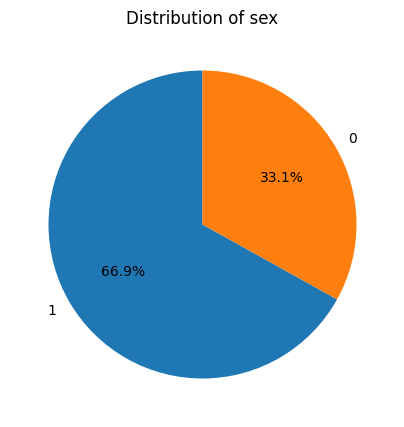

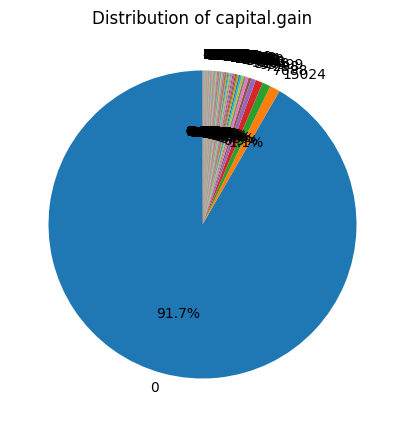

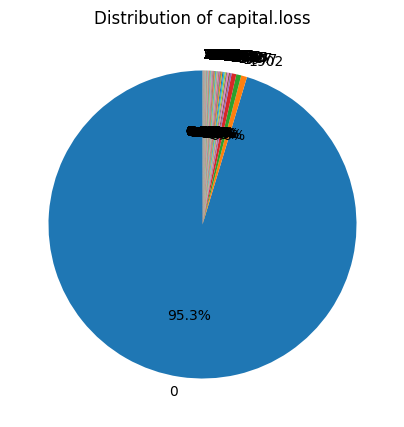

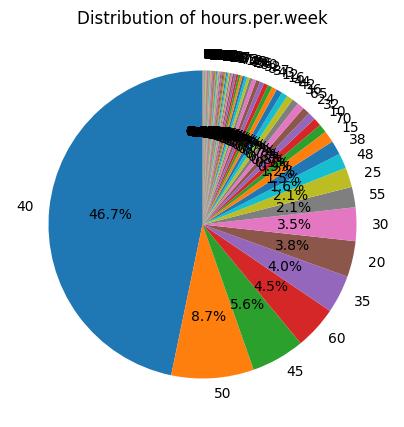

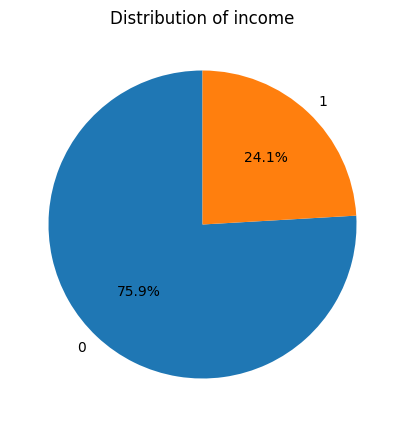

In [ ]:
plot_occurencies(df)

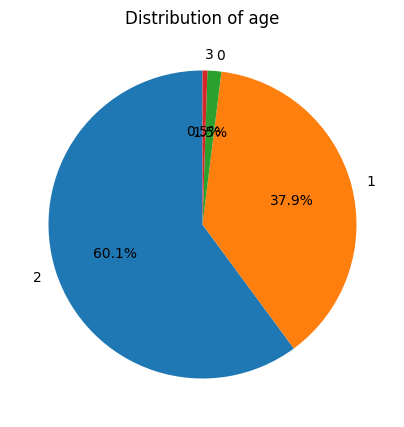

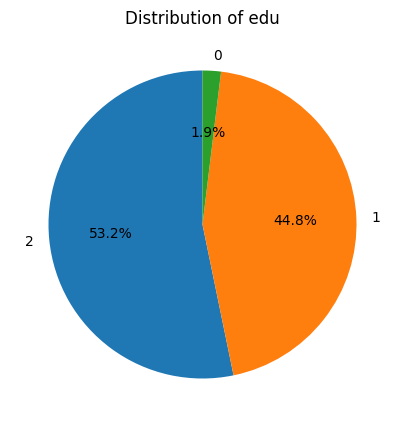

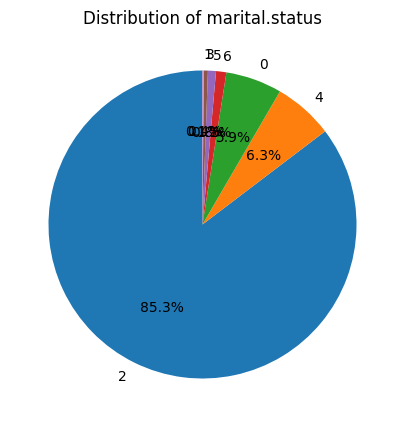

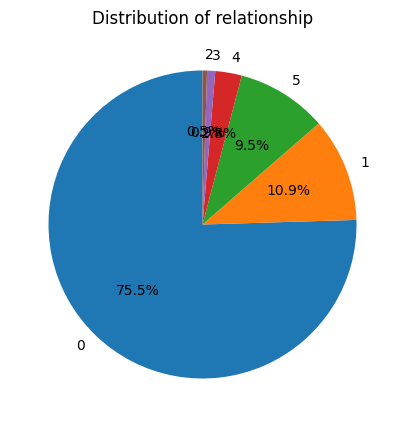

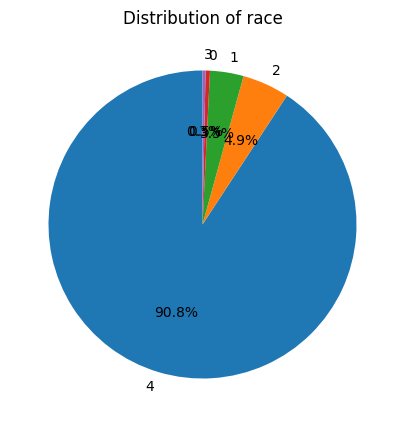

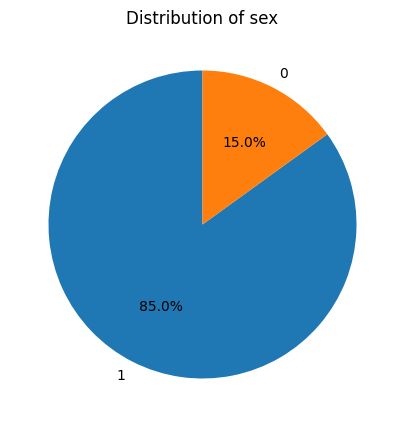

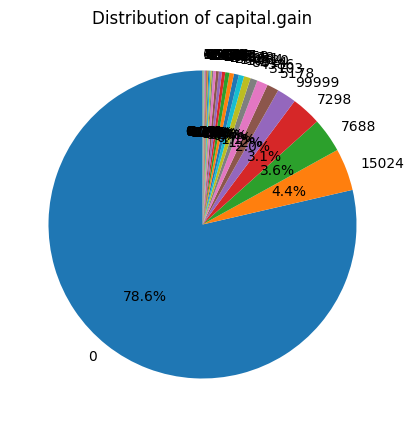

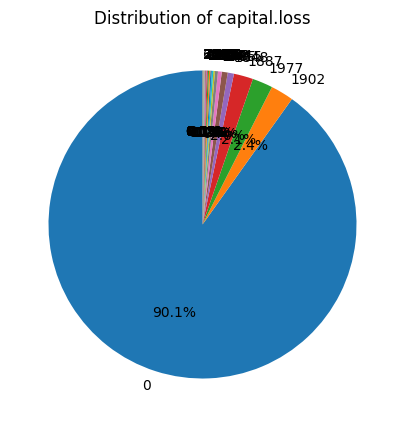

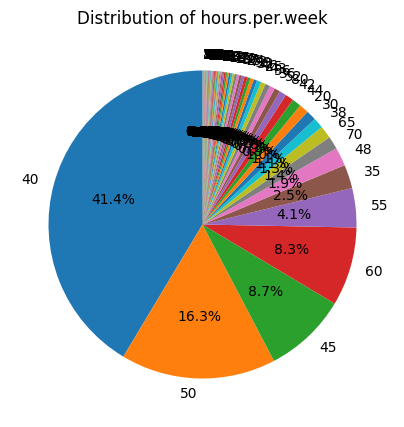

In [ ]:
# Filter dataset where column target class == 1
filtered_df = df[df['income'] == 1]
plot_occurencies(filtered_df, 'income')

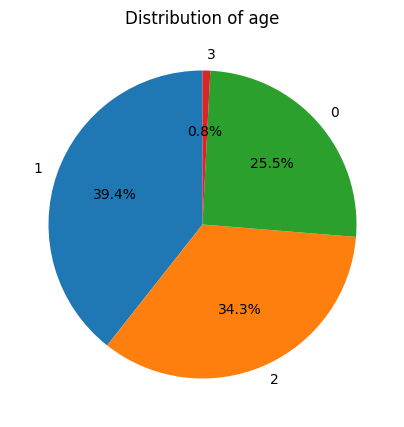

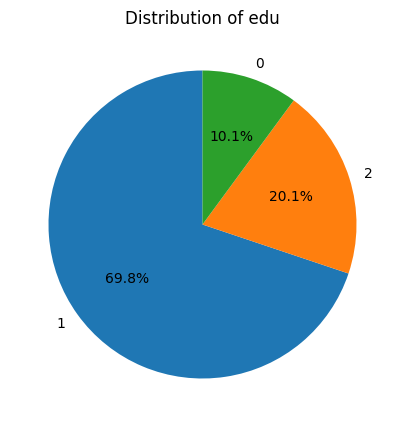

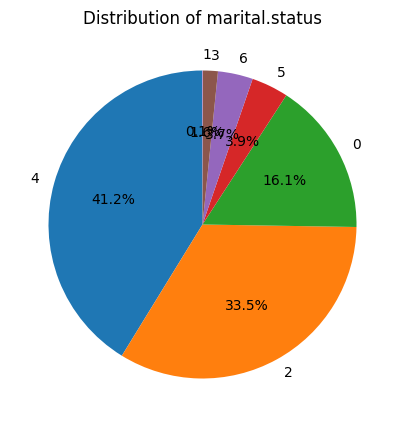

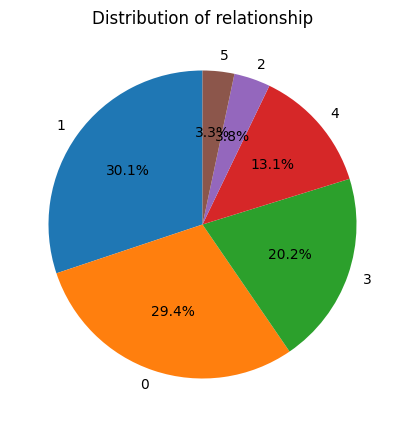

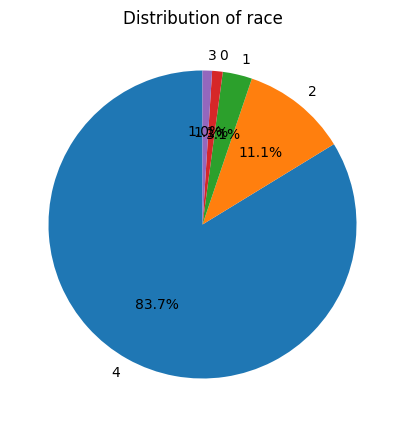

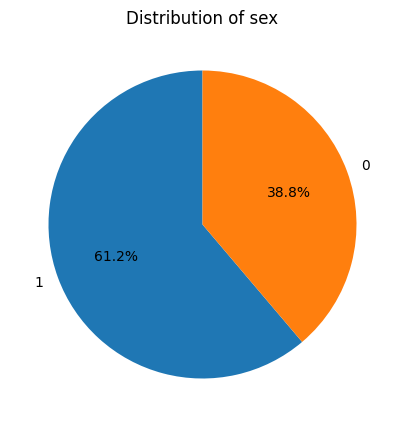

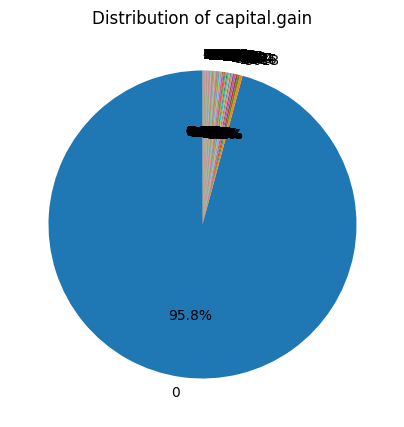

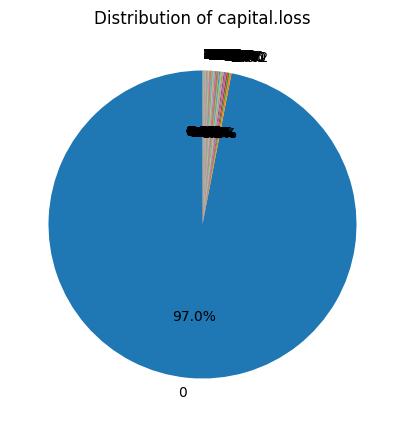

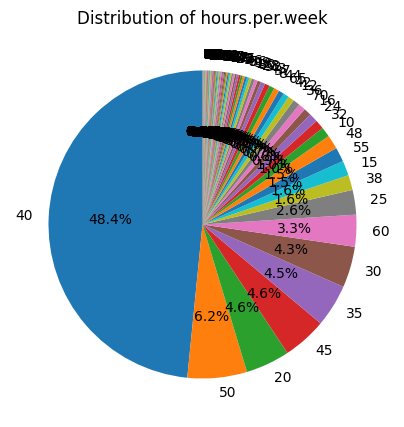

In [ ]:
# Filter dataset where column target class == 0
filtered_df = df[df['income'] == 0]
plot_occurencies(filtered_df, 'income')